In [1]:
2+2

4

In [2]:
# scipy, convert "C:\Users\101119\Documents\Sound Recordings\Recording (5).m4a" to spectrogram
# To convert an audio file (like "Recording (5).m4a") to a spectrogram using scipy, you can follow these steps:
import scipy.io.wavfile as wav
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
# test and run ffmpeg to convert m4a to wav
import subprocess
import os

# subprocess.run(['ffmpeg', '-i', 'C:\\Users\\101119\\Documents\\Sound Recordings\\Recording (2).m4a', 'Recording.wav'])

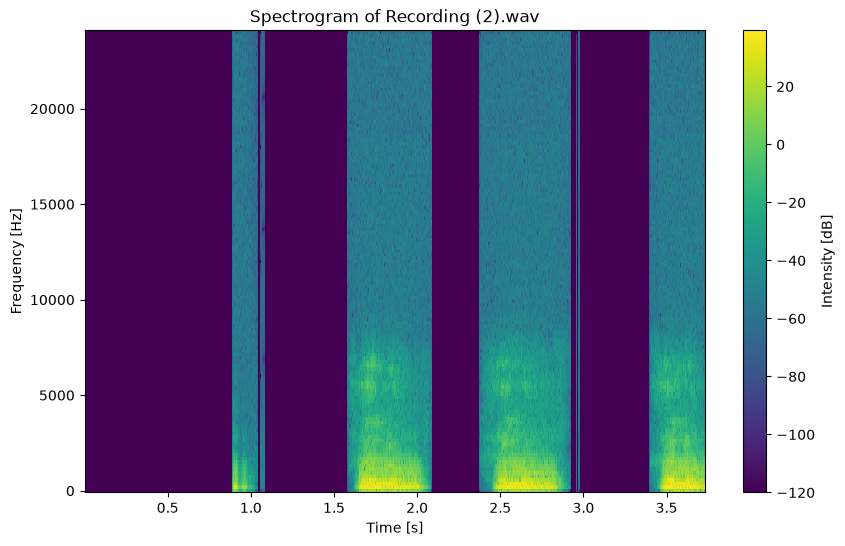

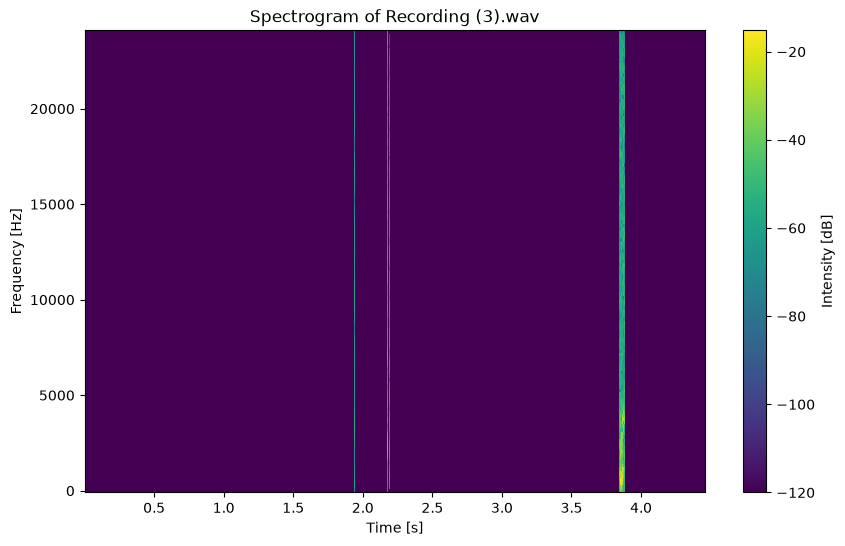

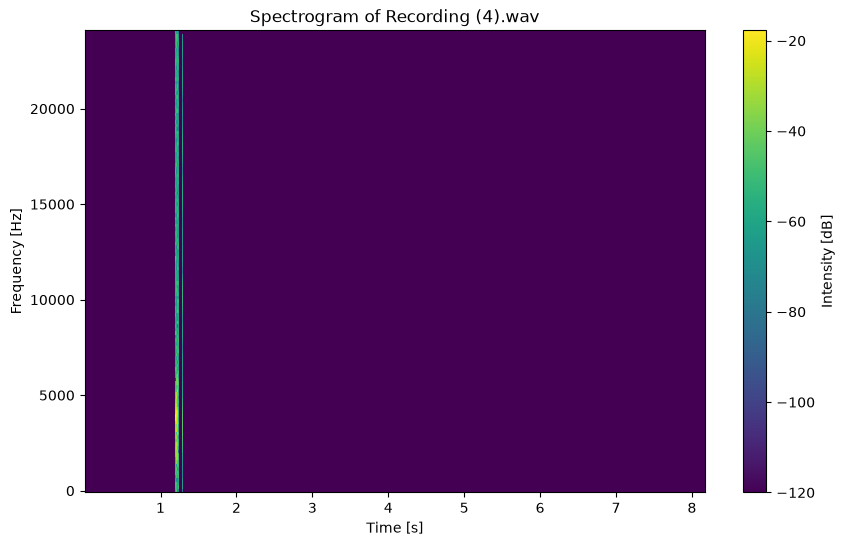

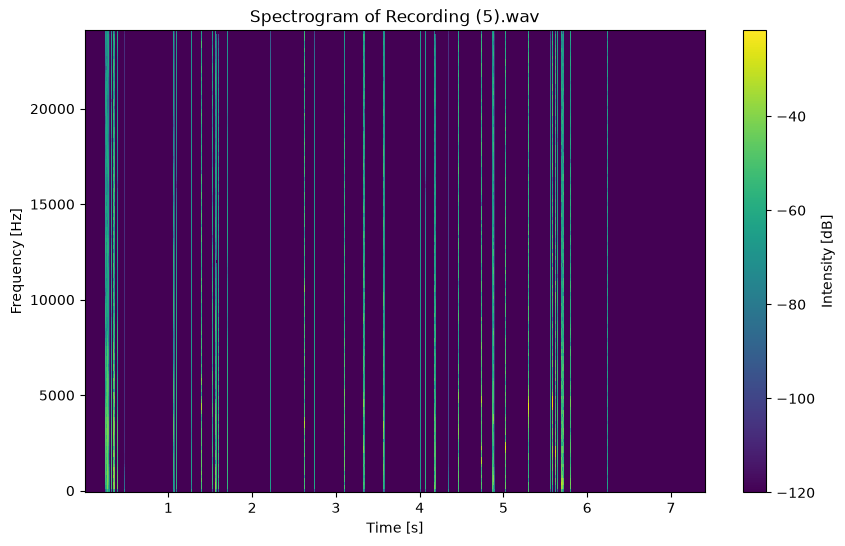

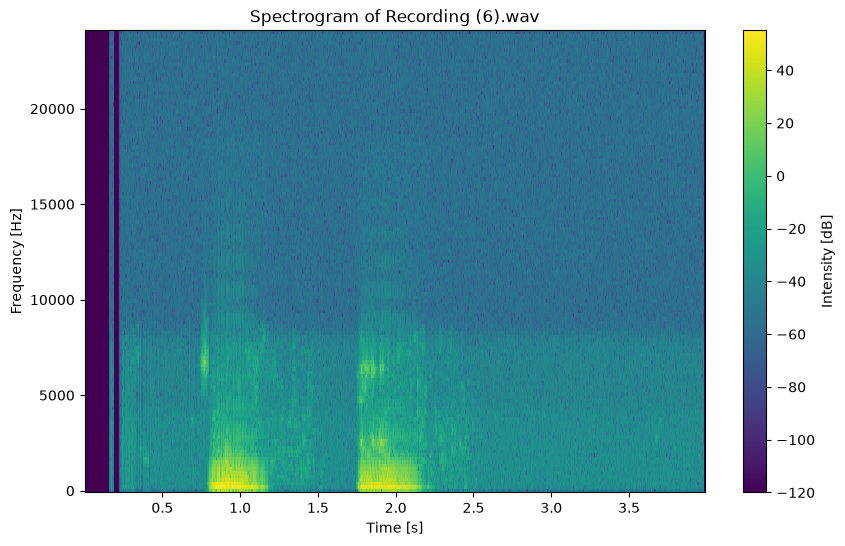

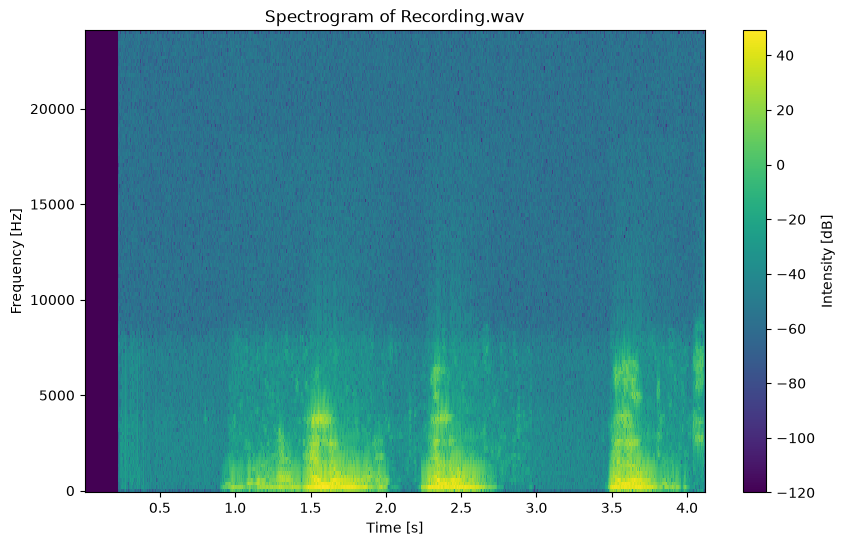

In [3]:
# Read and convert audio file to spectrogram safely in notebooks
from pathlib import Path

def flow(path):
    src = Path(path)
    # Keep output filename based on source basename, without full source path.
    wav_filename = src.with_suffix('.wav').name
    wav_path = str(Path.cwd() / wav_filename)

    try:
        # -y: overwrite output if needed, -nostdin: never wait for keyboard input.
        subprocess.run(
            ['ffmpeg', '-y', '-nostdin', '-hide_banner', '-loglevel', 'error', '-i', str(src), wav_path],
            check=True,
            stdin=subprocess.DEVNULL,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True,
        )
        sample_rate, audio_data = wav.read(wav_path)
        plot_spectrogram(audio_data, sample_rate, wav_path)
    except subprocess.CalledProcessError as e:
        print('ffmpeg failed:')
        print(e.stderr)
        raise

def plot_spectrogram(audio_data, sample_rate, wav_path):
    # Convert stereo/multi-channel audio to mono for spectrogram plotting
    audio_data = np.asarray(audio_data)
    if audio_data.ndim > 1:
        audio_data = audio_data.mean(axis=1)

    # Generate the spectrogram
    frequencies, times, Sxx = spectrogram(audio_data, fs=sample_rate)

    # Plot the spectrogram
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(times, frequencies, 10 * np.log10(Sxx + 1e-12), shading='auto')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [s]')
    plt.title(f'Spectrogram of {os.path.basename(wav_path)}')
    plt.colorbar(label='Intensity [dB]')
    plt.show()

# Call the function to plot the spectrogram

for file in os.listdir('C:\\Users\\101119\\Documents\\Sound Recordings'):
    if file.endswith('.m4a'):
        flow(os.path.join('C:\\Users\\101119\\Documents\\Sound Recordings', file))

In [4]:
# take "C:\Users\101119\Documents\Sound Recordings\Recording.m4a"
# split it into 2-second segments, with a stride of 1 second, and save each segment as real PCM .wav files.

import json
import math

def _get_audio_duration_seconds(path):
    result = subprocess.run(
        [
            'ffprobe', '-v', 'error',
            '-show_entries', 'format=duration',
            '-of', 'json',
            str(path),
        ],
        check=True,
        stdin=subprocess.DEVNULL,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
        text=True,
    )
    payload = json.loads(result.stdout)
    return float(payload['format']['duration'])

def split_save(path, segment_length=2, stride=1):
    src = Path(path)
    base_name = src.stem
    output_dir = Path.cwd() / f"{base_name}_segments"
    output_dir.mkdir(exist_ok=True)

    if segment_length <= 0 or stride <= 0:
        raise ValueError('segment_length and stride must be > 0')

    duration = _get_audio_duration_seconds(src)
    start_times = []
    t = 0.0
    # Generate overlapping windows with the requested stride.
    while t < duration:
        start_times.append(t)
        t += stride

    for i, start in enumerate(start_times):
        out_file = output_dir / f"{base_name}_{i:03d}.wav"
        try:
            subprocess.run(
                [
                    'ffmpeg', '-y', '-nostdin', '-hide_banner', '-loglevel', 'error',
                    '-ss', f"{start:.3f}",
                    '-i', str(src),
                    '-t', str(segment_length),
                    # Force true WAV format that scipy can read.
                    '-acodec', 'pcm_s16le',
                    '-ar', '16000',
                    '-ac', '1',
                    str(out_file),
                ],
                check=True,
                stdin=subprocess.DEVNULL,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
            )
        except subprocess.CalledProcessError as e:
            print(f'ffmpeg failed for segment {i} starting at {start:.3f}s:')
            print(e.stderr)
            raise

    print(f"Generated {len(start_times)} segment(s) in: {output_dir}")

In [7]:
split_save('C:\\Users\\101119\\Documents\\Sound Recordings\\Recording (2).m4a', segment_length=2, stride=1)

Generated 4 segment(s) in: d:\NeuralNetworks-ML-AI\Recording (2)_segments


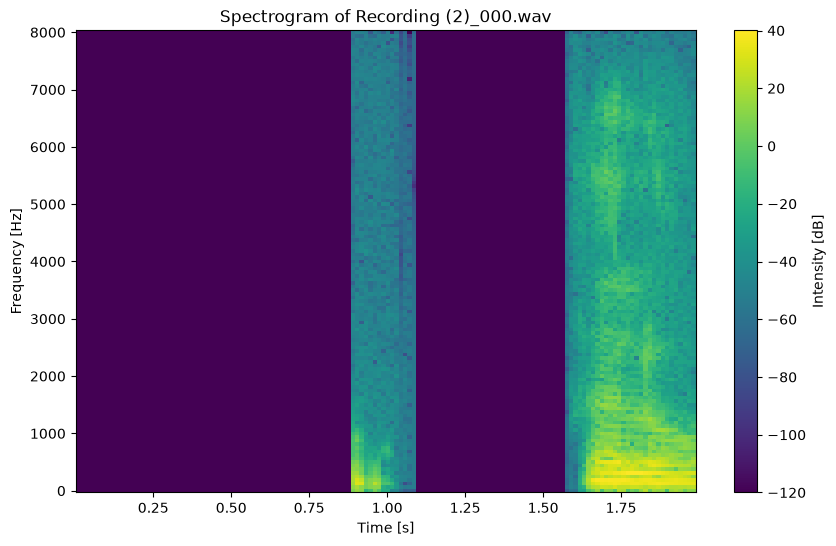

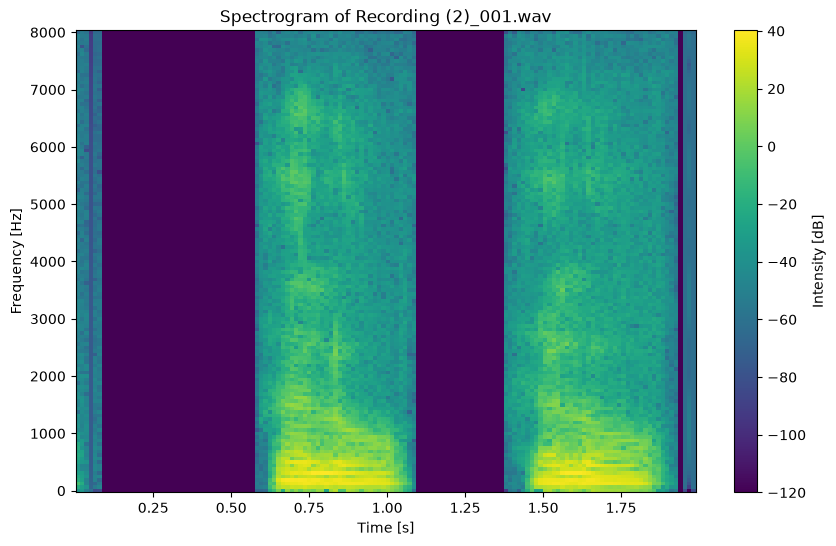

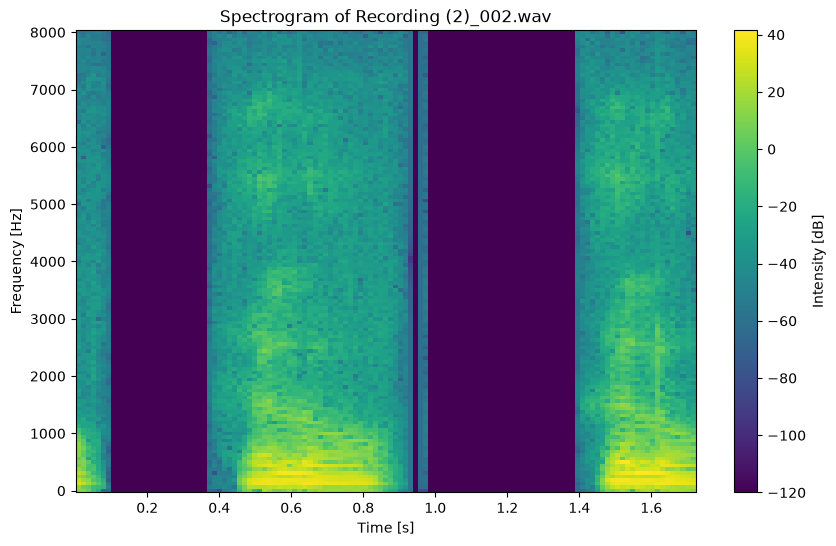

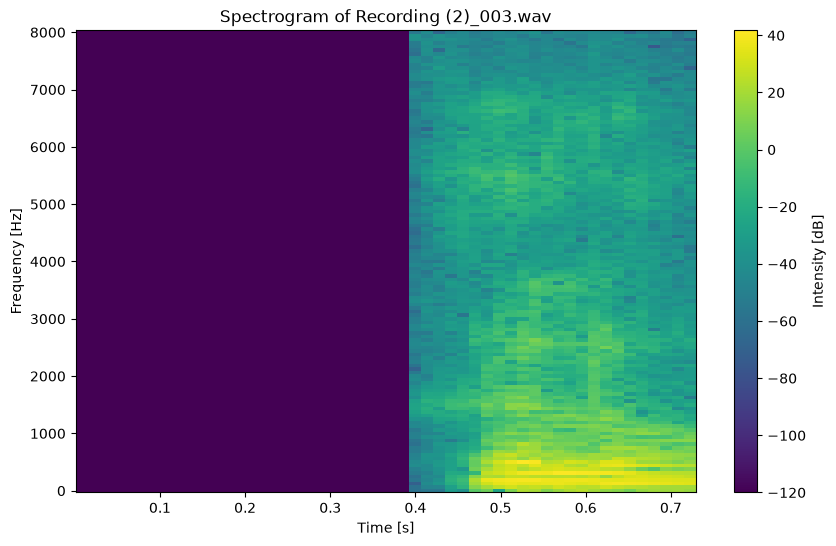

In [9]:
for file in os.listdir('Recording (2)_segments'):
    if file.endswith('.wav'):
        wav_path = os.path.join('Recording (2)_segments', file)
        sample_rate, audio_data = wav.read(wav_path)
        plot_spectrogram(audio_data, sample_rate, wav_path)